In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
import seaborn as sns
from sklearn.preprocessing import RobustScaler, PowerTransformer, StandardScaler

In [2]:
dataset = pd.read_csv("../data/processed_dataset/final_2d_cleaned_dataset.csv")
dataset

,Unnamed: 0,stat_mean,stat_var,stat_skew,stat_kurt,stat_median,stat_min,stat_p10,stat_p90,stat_max,...,stat_range,stat_mad,stat_medad,stat_cov,stat_qcod,stat_energy,stat_rms,patient_id,ct_image_path,mask_path
0,0,41.247726,1279.65260,-0.252790,0.356391,43.0,-99.0,-4.0,86.0,157.0,...,256.0,28.393686,28.338726,0.867253,0.576471,2948236.0,54.598785,4403,/home/benmagni@uca.local/radiomic-internship/d...,/home/benmagni@uca.local/radiomic-internship/d...
1,1,44.144756,1101.50440,-0.089653,0.023318,46.0,-71.0,0.0,85.0,171.0,...,242.0,26.461044,26.438208,0.751820,0.522727,6195086.0,55.229195,4403,/home/benmagni@uca.local/radiomic-internship/d...,/home/benmagni@uca.local/radiomic-internship/d...
2,2,35.316345,1555.30530,-0.406549,0.812776,38.0,-143.0,-13.0,85.0,180.0,...,323.0,30.724237,30.681168,1.116689,0.671233,4509302.0,52.939110,4403,/home/benmagni@uca.local/radiomic-internship/d...,/home/benmagni@uca.local/radiomic-internship/d...
3,3,41.412292,1159.32120,0.087044,0.020695,41.5,-73.0,-1.0,86.0,146.0,...,219.0,26.895718,26.895718,0.822191,0.560976,4161985.0,53.612490,4403,/home/benmagni@uca.local/radiomic-internship/d...,/home/benmagni@uca.local/radiomic-internship/d...
4,4,32.931625,1517.24460,-0.456880,0.900688,35.0,-121.0,-17.0,80.0,166.0,...,287.0,29.755596,29.678322,1.182809,0.685714,3348435.0,51.007220,4403,/home/benmagni@uca.local/radiomic-internship/d...,/home/benmagni@uca.local/radiomic-internship/d...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57645,57645,22.853968,772.22003,-1.069019,1.569384,28.0,-92.0,-15.6,52.0,76.0,...,168.0,21.322450,20.904762,1.215931,0.647059,407775.0,35.979492,939,/home/benmagni@uca.local/radiomic-internship/d...,/home/benmagni@uca.local/radiomic-internship/d...
57646,57646,19.587538,835.51240,-0.574469,0.393471,22.0,-71.0,-18.0,54.0,82.0,...,153.0,22.488460,22.430267,1.475695,0.902439,410865.0,34.916817,939,/home/benmagni@uca.local/radiomic-internship/d...,/home/benmagni@uca.local/radiomic-internship/d...
57647,57647,35.916668,138.07637,-0.187407,-0.127105,35.5,11.0,26.1,52.1,56.0,...,45.0,9.083333,9.083333,0.327163,0.197183,17137.0,37.789990,939,/home/benmagni@uca.local/radiomic-internship/d...,/home/benmagni@uca.local/radiomic-internship/d...
57648,57648,8.428572,2035.73340,-0.548886,0.159441,14.0,-124.0,-60.0,61.0,123.0,...,247.0,34.748615,34.359913,5.353114,2.061224,1902417.0,45.899610,939,/home/benmagni@uca.local/radiomic-internship/d...,/home/benmagni@uca.local/radiomic-internship/d...


In [3]:
dataset.columns

Index(['Unnamed: 0', 'stat_mean', 'stat_var', 'stat_skew', 'stat_kurt',
       'stat_median', 'stat_min', 'stat_p10', 'stat_p90', 'stat_max',
       'stat_iqr', 'stat_range', 'stat_mad', 'stat_medad', 'stat_cov',
       'stat_qcod', 'stat_energy', 'stat_rms', 'patient_id', 'ct_image_path',
       'mask_path'],
      dtype='str')

### Cohérence entre métriques similaires

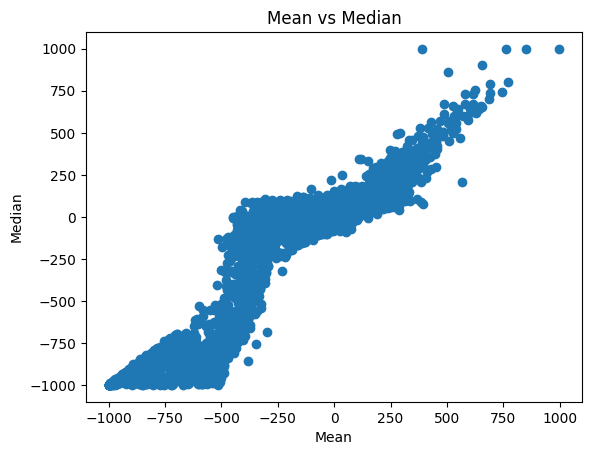

In [5]:
plt.scatter(dataset['stat_mean'], dataset['stat_median'])
plt.xlabel("Mean")
plt.ylabel("Median")
plt.title("Mean vs Median")
plt.show()

In [6]:
print("RMS ≥ Mean: ", (dataset['stat_rms'] < dataset['stat_mean']).sum())
print("Min ≤ Median ≤ Max: ", ((dataset['stat_min'] > dataset['stat_median']) | (dataset['stat_median'] > dataset['stat_max'])).sum())

RMS ≥ Mean:  0
Min ≤ Median ≤ Max:  0


### Détection de valeurs extrêmes

In [7]:
z = np.abs(zscore(dataset.iloc[:,1:18]))
outliers = (z > 5).sum(axis=0)

print("outliers", outliers)

outliers [ 646  668  197  366  889    0    1  577  145 1071    0  600  646    0
  220  383  610]


/home/benmagni@uca.local/miniconda3/envs/youssef-internship/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1162: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


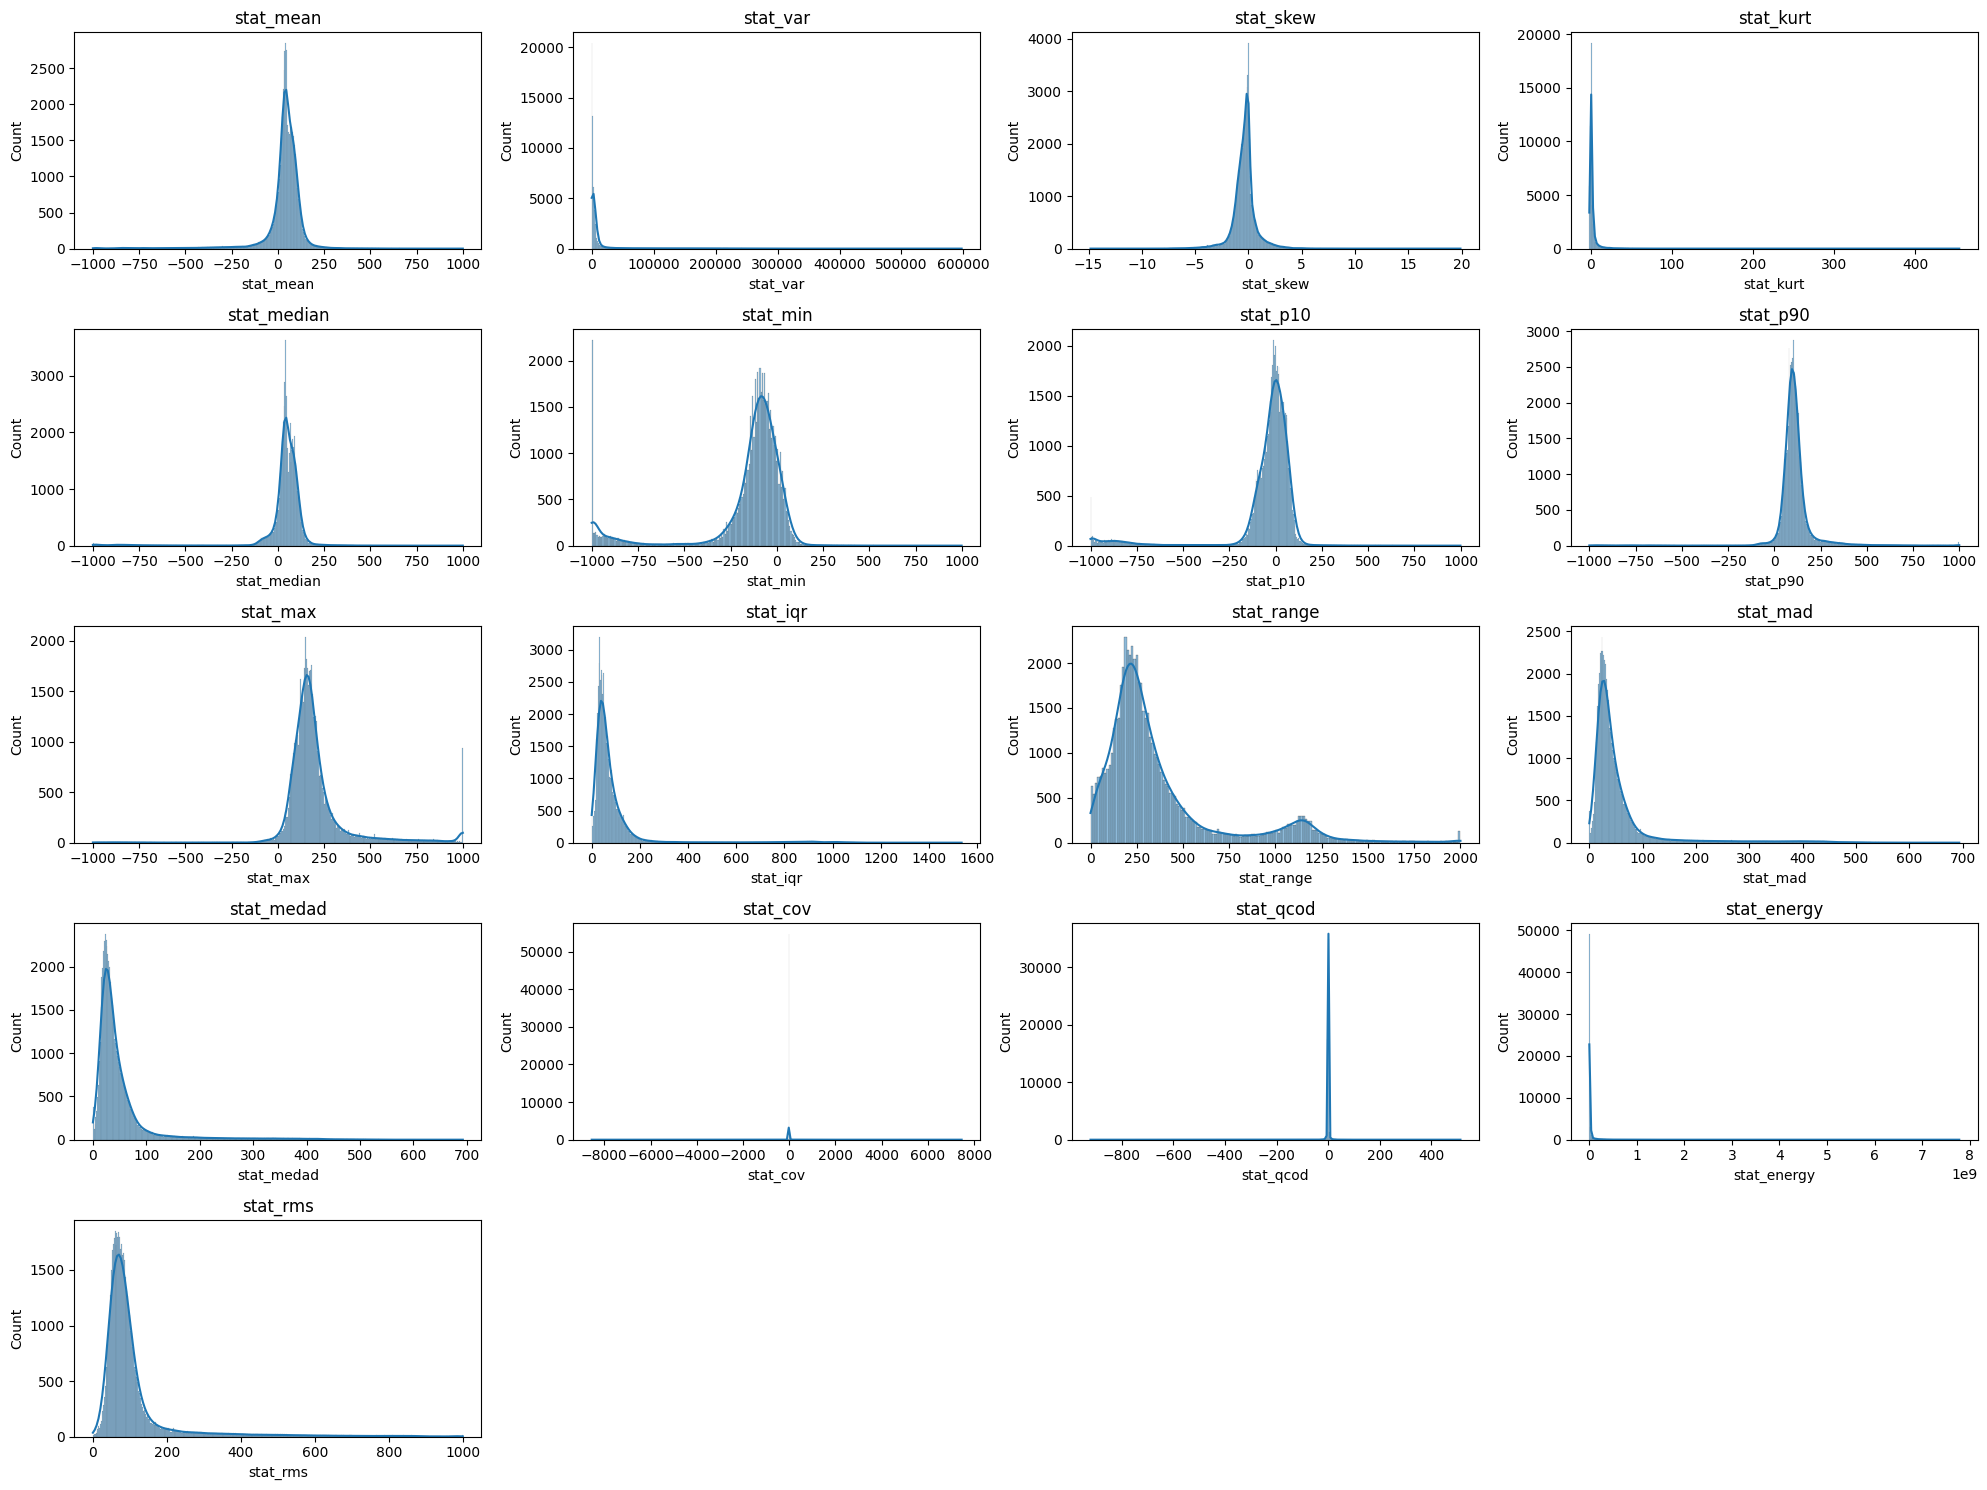

In [8]:
cols = dataset.columns[1:18]

n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(dataset[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### StanderdScaler effect

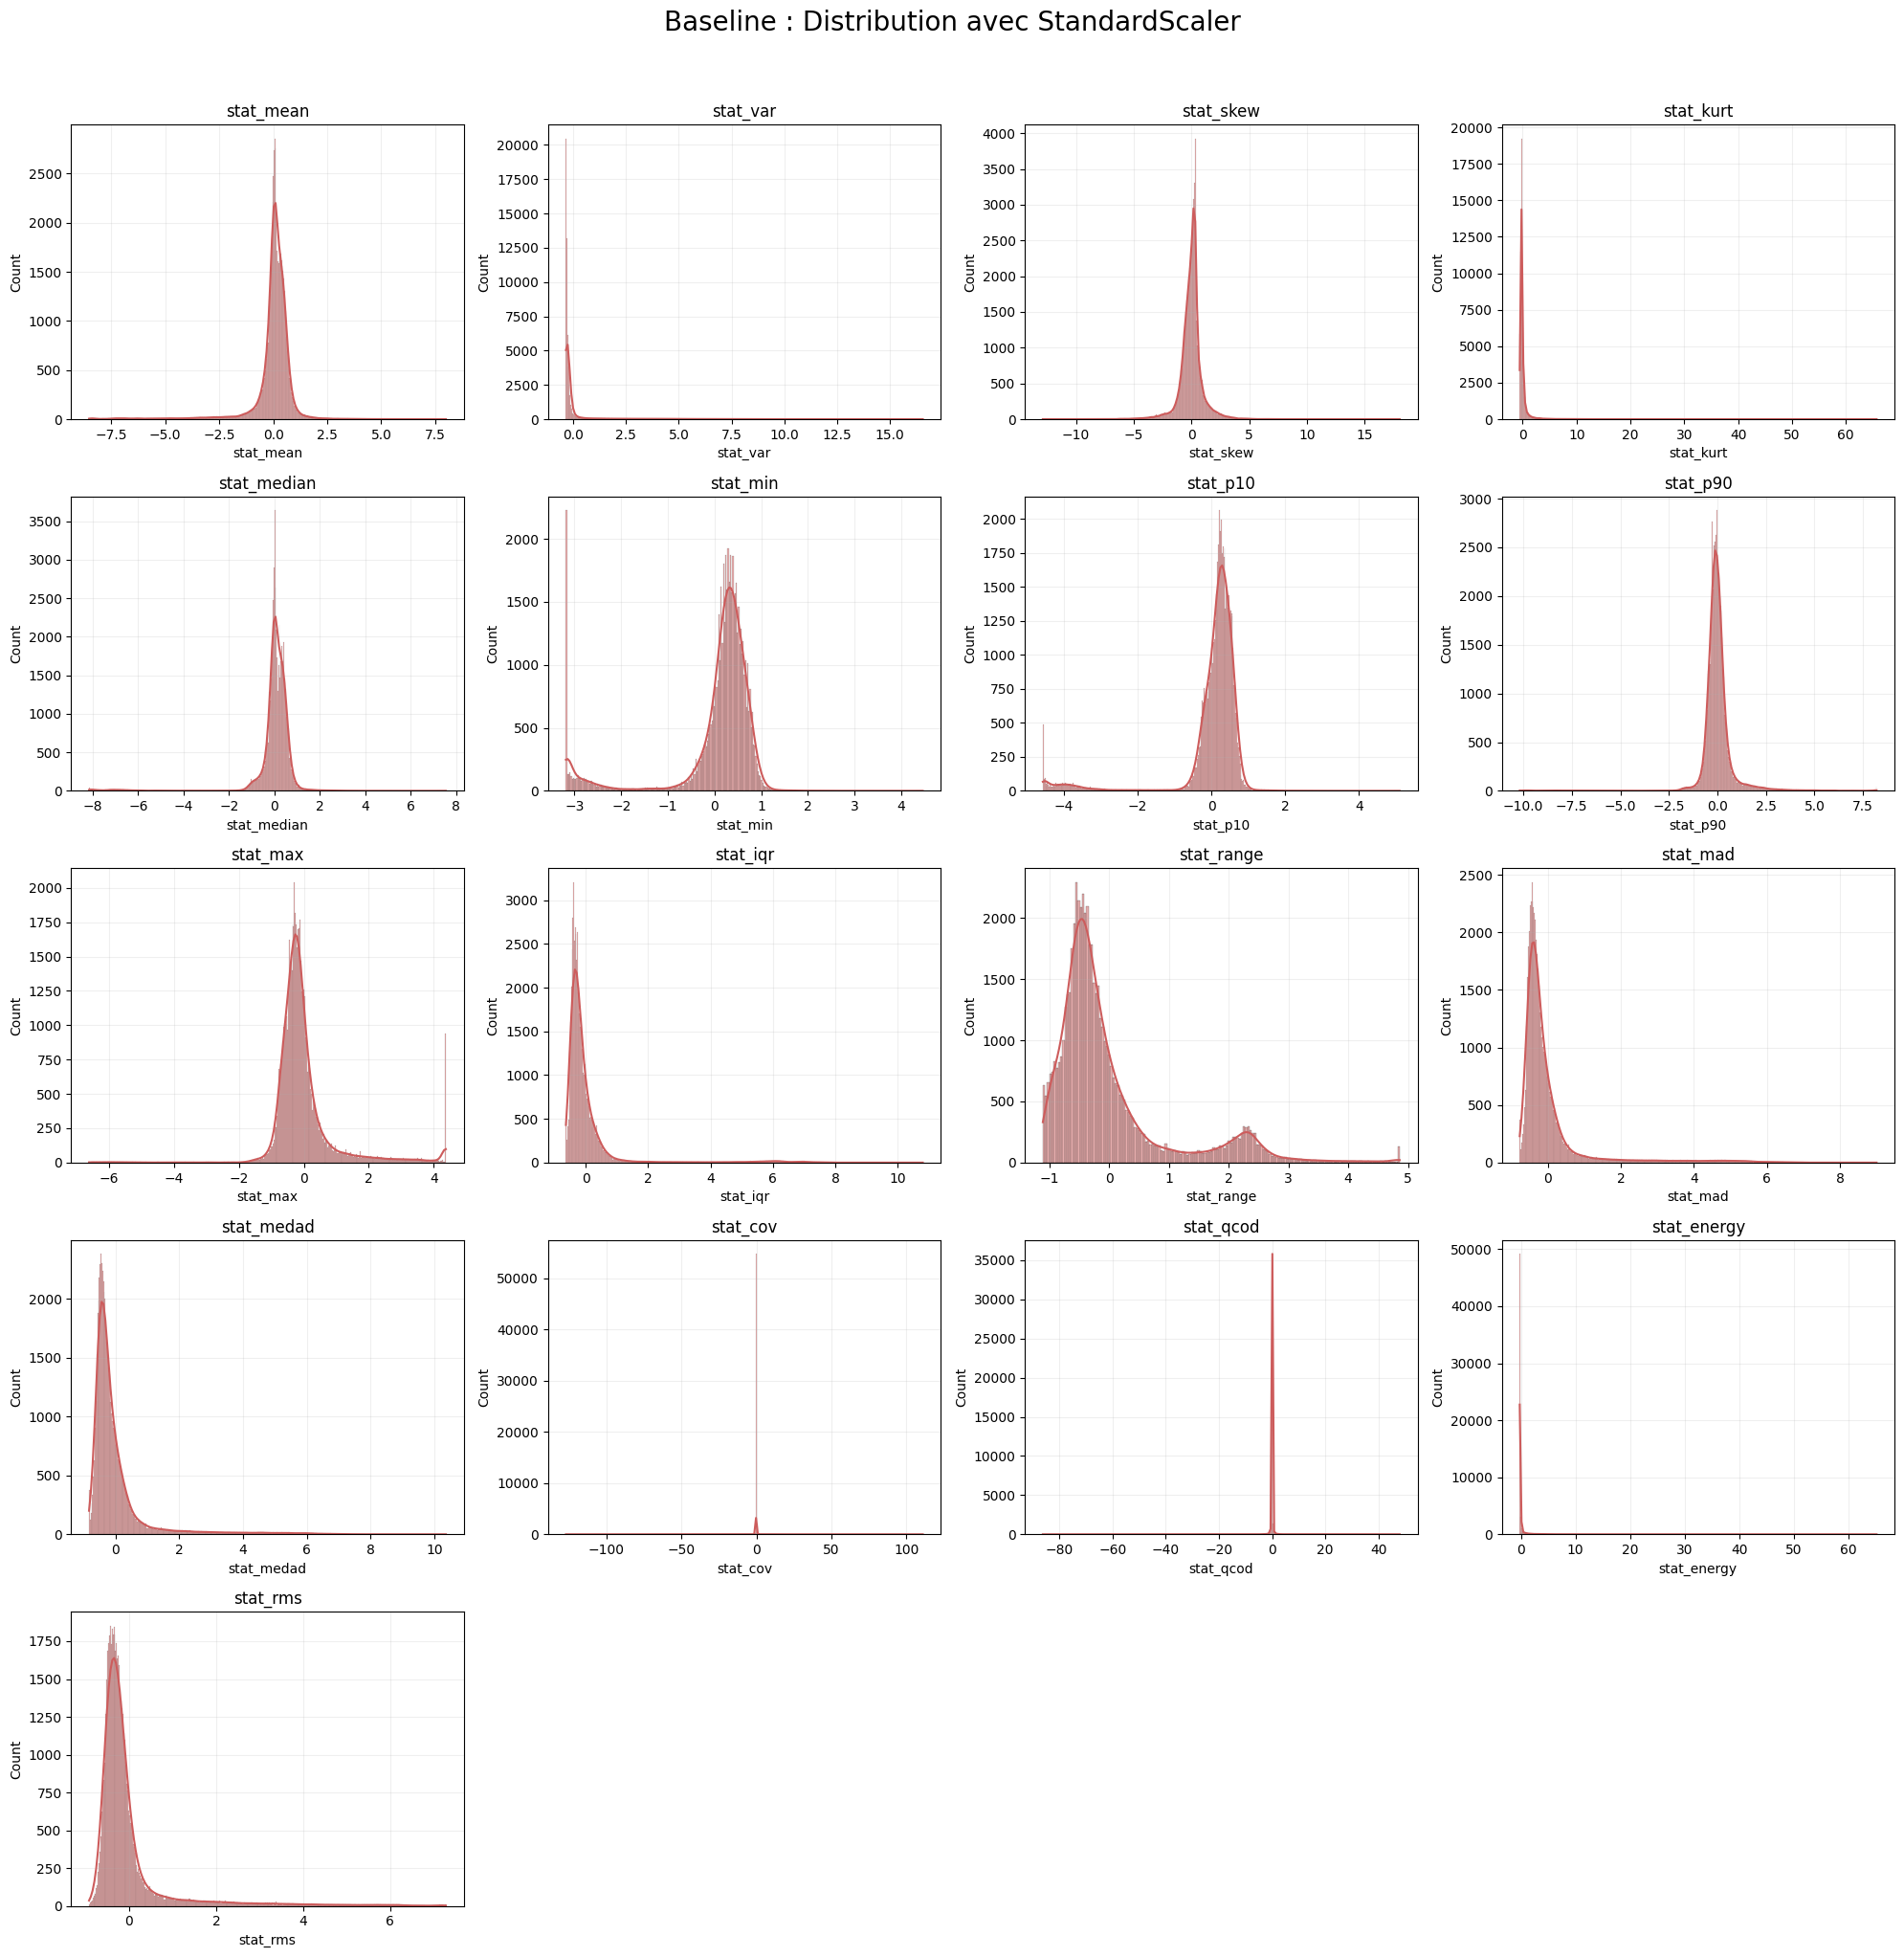

In [35]:
target_cols = [c for c in dataset.columns if c.startswith("stat_")]
df_raw = dataset.copy()
df_raw[target_cols] = df_raw[target_cols].replace([np.inf, -np.inf], np.nan)
df_raw[target_cols] = df_raw[target_cols].fillna(df_raw[target_cols].median())

# 2. Application du StandardScaler Pur
scaler_std = StandardScaler()
df_std = df_raw.copy()
df_std[target_cols] = scaler_std.fit_transform(df_std[target_cols])

# 3. Visualisation (comparaison sur une feature critique comme stat_energy)
def plot_standard_comparison(df_transformed, columns):
    num_cols = 4
    num_rows = int(np.ceil(len(columns) / num_cols))
    
    plt.figure(figsize=(20, 4 * num_rows))
    for i, col in enumerate(columns):
        plt.subplot(num_rows, num_cols, i + 1)
        sns.histplot(df_transformed[col], kde=True, color="indianred")
        plt.title(f"{col}")
        plt.grid(alpha=0.2)
        
    plt.suptitle("Baseline : Distribution avec StandardScaler", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

plot_standard_comparison(df_std, target_cols)

### Robust Scaler effect

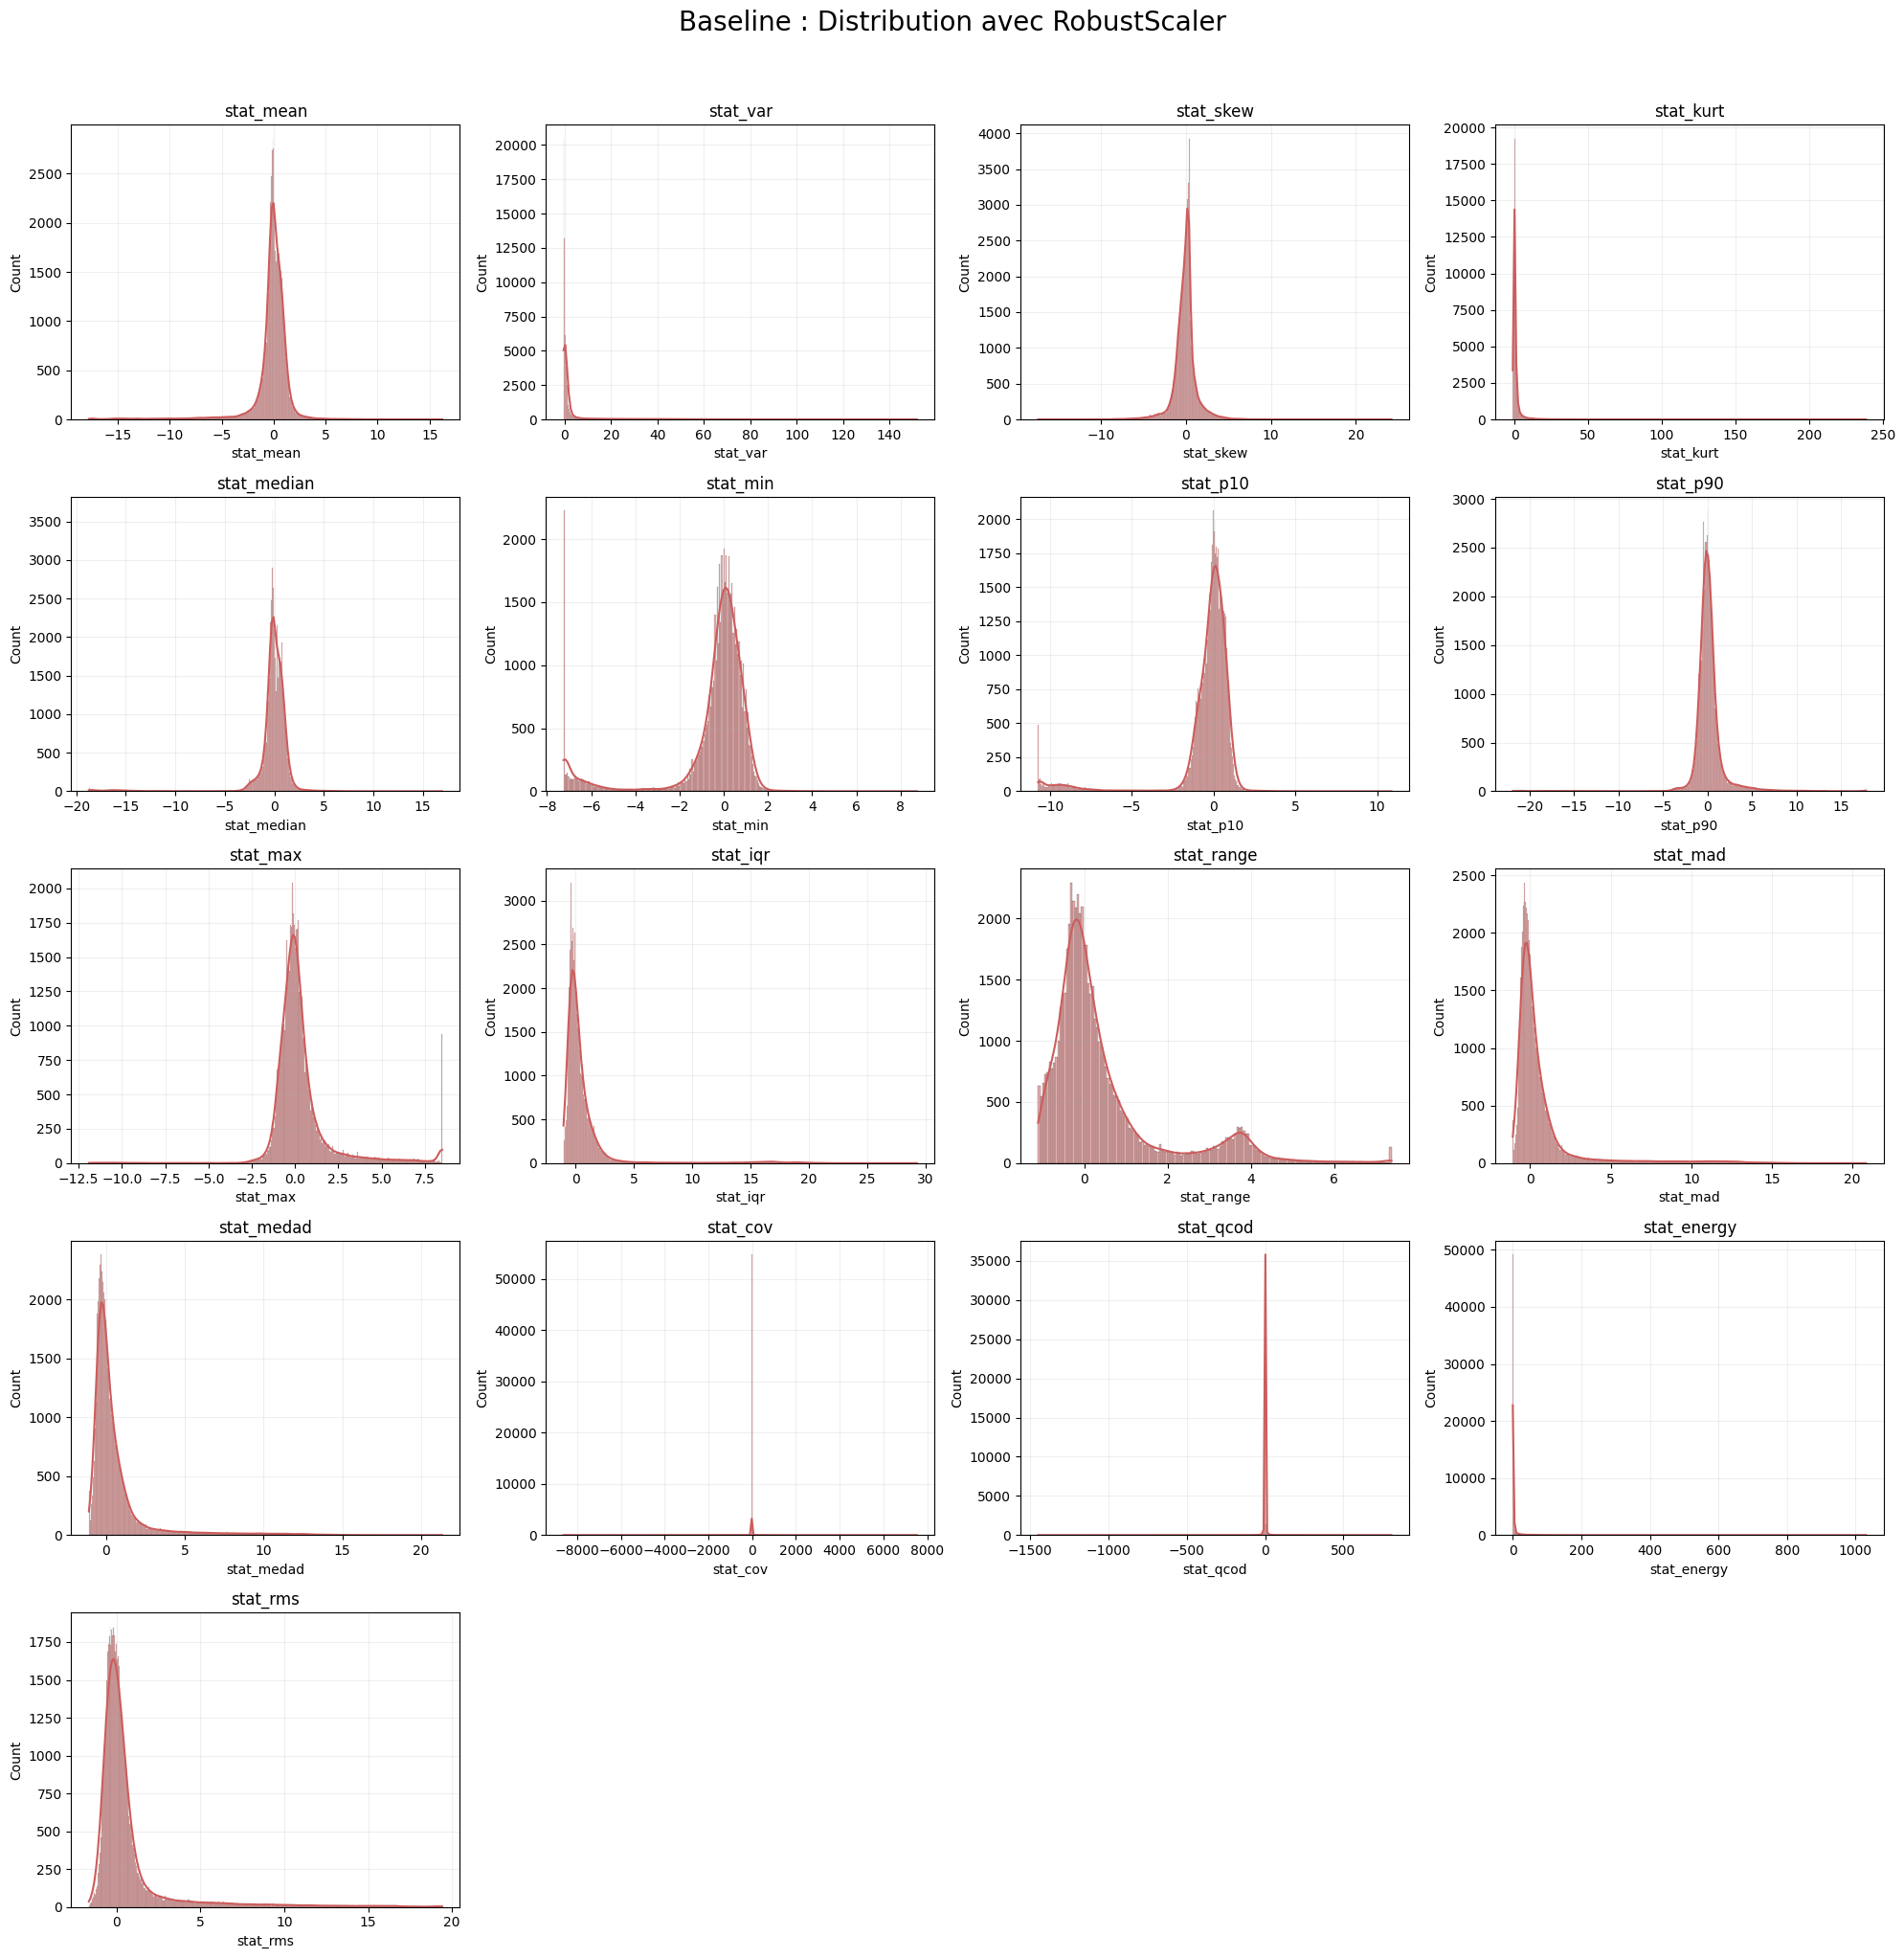

In [34]:
target_cols = [c for c in dataset.columns if c.startswith("stat_")]
df_raw = dataset.copy()
df_raw[target_cols] = df_raw[target_cols].replace([np.inf, -np.inf], np.nan)
df_raw[target_cols] = df_raw[target_cols].fillna(df_raw[target_cols].median())

# 2. Application du StandardScaler Pur
scaler_std = RobustScaler()
df_std = df_raw.copy()
df_std[target_cols] = scaler_std.fit_transform(df_std[target_cols])

# 3. Visualisation (comparaison sur une feature critique comme stat_energy)
def plot_standard_comparison(df_transformed, columns):
    num_cols = 4
    num_rows = int(np.ceil(len(columns) / num_cols))
    
    plt.figure(figsize=(20, 4 * num_rows))
    for i, col in enumerate(columns):
        plt.subplot(num_rows, num_cols, i + 1)
        sns.histplot(df_transformed[col], kde=True, color="indianred")
        plt.title(f"{col}")
        plt.grid(alpha=0.2)
        
    plt.suptitle("Baseline : Distribution avec RobustScaler", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

plot_standard_comparison(df_std, target_cols)

In [10]:
def plot_log_comparison(data, features):
    n_features = len(features)
    fig, axes = plt.subplots(n_features, 2, figsize=(15, 4 * n_features))
    plt.subplots_adjust(hspace=0.4)

    for i, col in enumerate(features):
        if col not in data.columns:
            continue
            
        sns.histplot(data[col], kde=True, ax=axes[i, 0], color="indianred")
        axes[i, 0].set_title(f"Original: {col}")
        
        log_data = np.log1p(data[col].clip(lower=0)) 
        sns.histplot(log_data, kde=True, ax=axes[i, 1], color="royalblue")
        axes[i, 1].set_title(f"Log1p Transformed: {col}")

    plt.suptitle("Impact of Log1p Transformation", fontsize=20, y=1.01)
    plt.tight_layout()
    plt.show()

### By group transformation effect

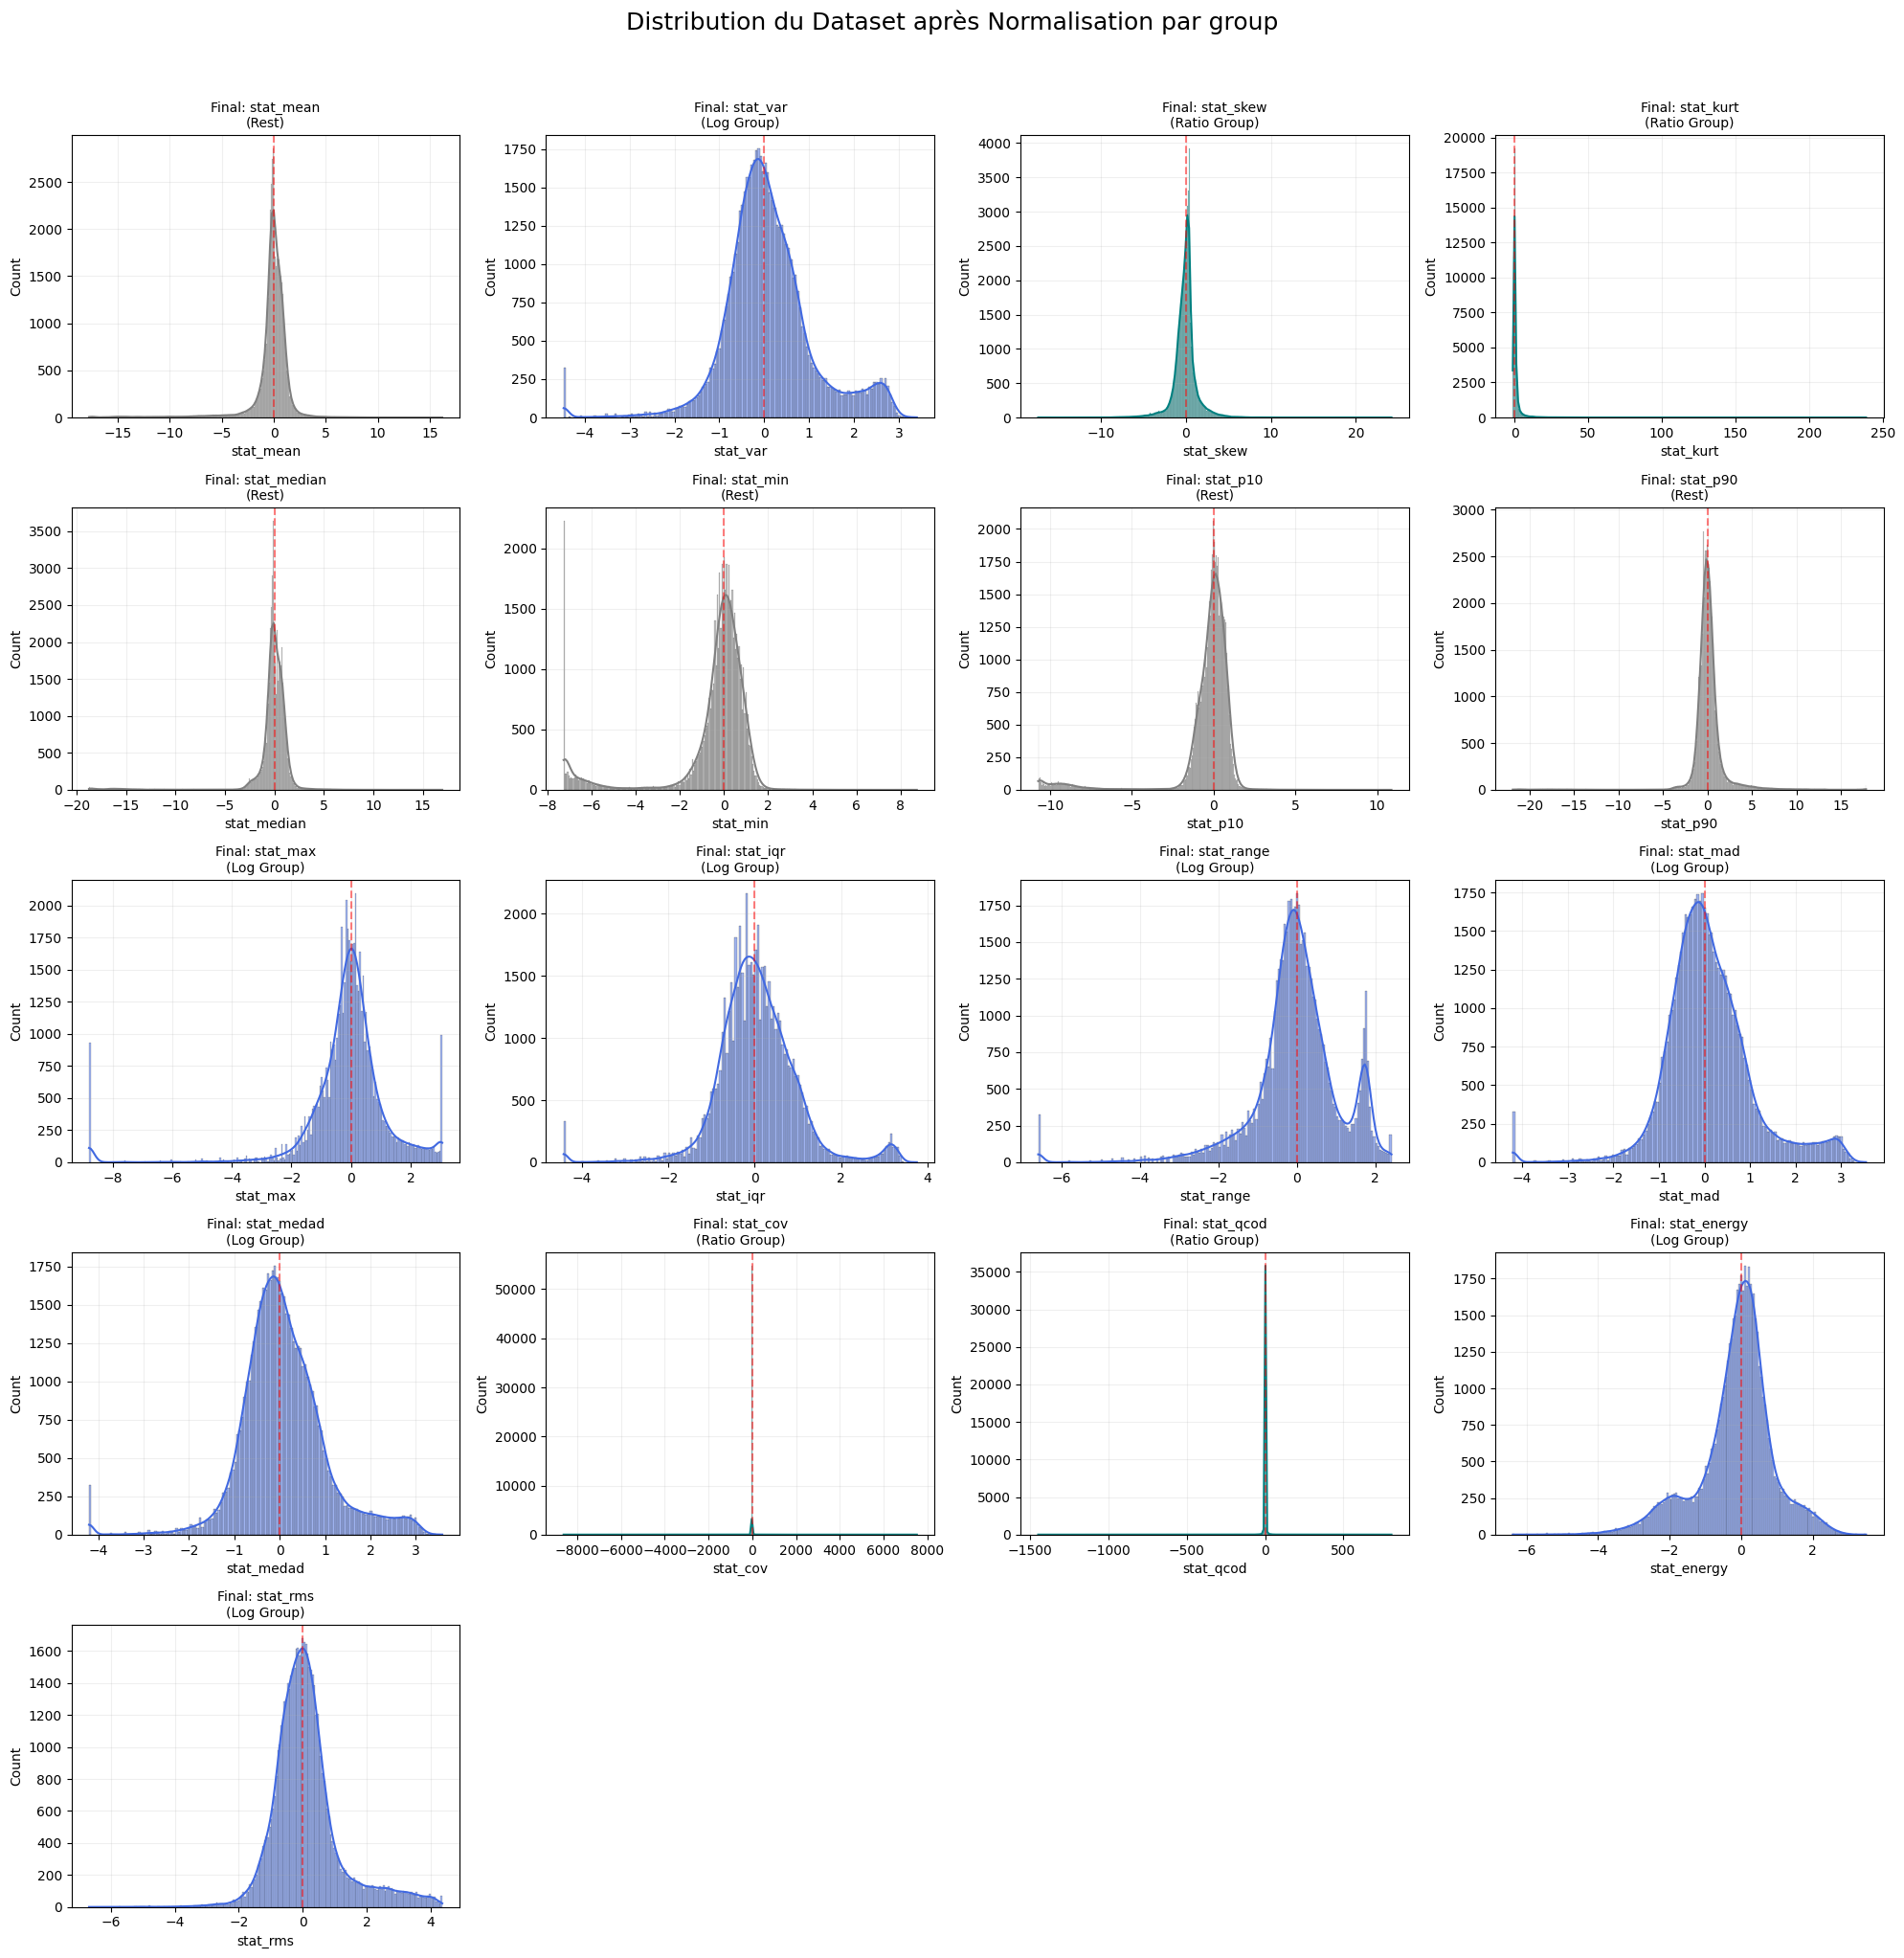

In [38]:
def custom_scaling_v2(dataset: pd.DataFrame,target_cols: list, log_features: list, ratio_features: list, is_train: bool, scaler: dict | None = None) -> tuple[pd.DataFrame, dict | None]:
    """
    Three-group scaling strategy:
      - ratio features  -> RobustScaler only
      - log features    -> log1p, then RobustScaler
      - rest            -> RobustScaler
 
    """
    dataset = dataset.replace([np.inf, -np.inf], np.nan).dropna()
    df = dataset.copy()
 
    # Separate features that exist in the dataframe
    ratio_cols = [c for c in ratio_features if c in target_cols]
    log_cols   = [c for c in log_features   if c in target_cols]
    rest_cols  = [c for c in target_cols if c not in ratio_cols and c not in log_cols]
 
    if is_train:
        scaler = {}
 
        # Ratio group — RobustScaler only
        if ratio_cols:
            sc = RobustScaler()
            df[ratio_cols] = sc.fit_transform(df[ratio_cols])
            scaler["ratio"] = (sc, ratio_cols, False)   # (scaler, cols, log_transform)
 
        # Log group — log1p then RobustScaler
        if log_cols:
            df[log_cols] = np.log1p(df[log_cols].clip(lower=0))
            sc = RobustScaler()
            df[log_cols] = sc.fit_transform(df[log_cols])
            scaler["log"] = (sc, log_cols, True)
 
        # Rest group — RobustScaler only
        if rest_cols:
            sc = RobustScaler()
            df[rest_cols] = sc.fit_transform(df[rest_cols])
            scaler["rest"] = (sc, rest_cols, False)
 
        return df, scaler
 
    else:
        assert scaler is not None, "scaler must be provided for val/test"
 
        for key, (sc, cols, do_log) in scaler.items():
            valid = [c for c in cols if c in df.columns]
            if do_log:
                df[valid] = np.log1p(df[valid].clip(lower=0))
            df[valid] = sc.transform(df[valid])
 
        return df, None

def plot_final_distributions(df_scaled, target_cols):
    num_features = len(target_cols)
    num_cols = 4
    num_rows = int(np.ceil(num_features / num_cols))
    
    plt.figure(figsize=(20, 4 * num_rows))
    
    for i, col in enumerate(target_cols):
        plt.subplot(num_rows, num_cols, i + 1)
        
        # Coloration par groupe pour une meilleure lisibilité
        if col in LOG_FEATURES:
            color = "royalblue"
            label = "Log Group"
        elif col in RATIO_FEATURES:
            color = "teal"
            label = "Ratio Group"
        else:
            color = "gray"
            label = "Rest"
            
        sns.histplot(df_scaled[col], kde=True, color=color)
        plt.title(f"Final: {col}\n({label})", fontsize=10)
        plt.axvline(0, color='red', linestyle='--', alpha=0.5) # Ligne de centrage
        plt.grid(alpha=0.2)
        
    plt.suptitle("Distribution du Dataset après Normalisation par group", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

target_cols = [c for c in dataset.columns if c.startswith("stat_")]
LOG_FEATURES = ["stat_energy", "stat_var", "stat_range", "stat_iqr", "stat_mad", "stat_medad", "stat_max", "stat_rms"]
RATIO_FEATURES = ["stat_qcod", "stat_cov", "stat_skew", "stat_kurt"]

df_scaled, _ = custom_scaling_v2(dataset, target_cols, LOG_FEATURES, RATIO_FEATURES, is_train=True)

plot_final_distributions(df_scaled, target_cols)

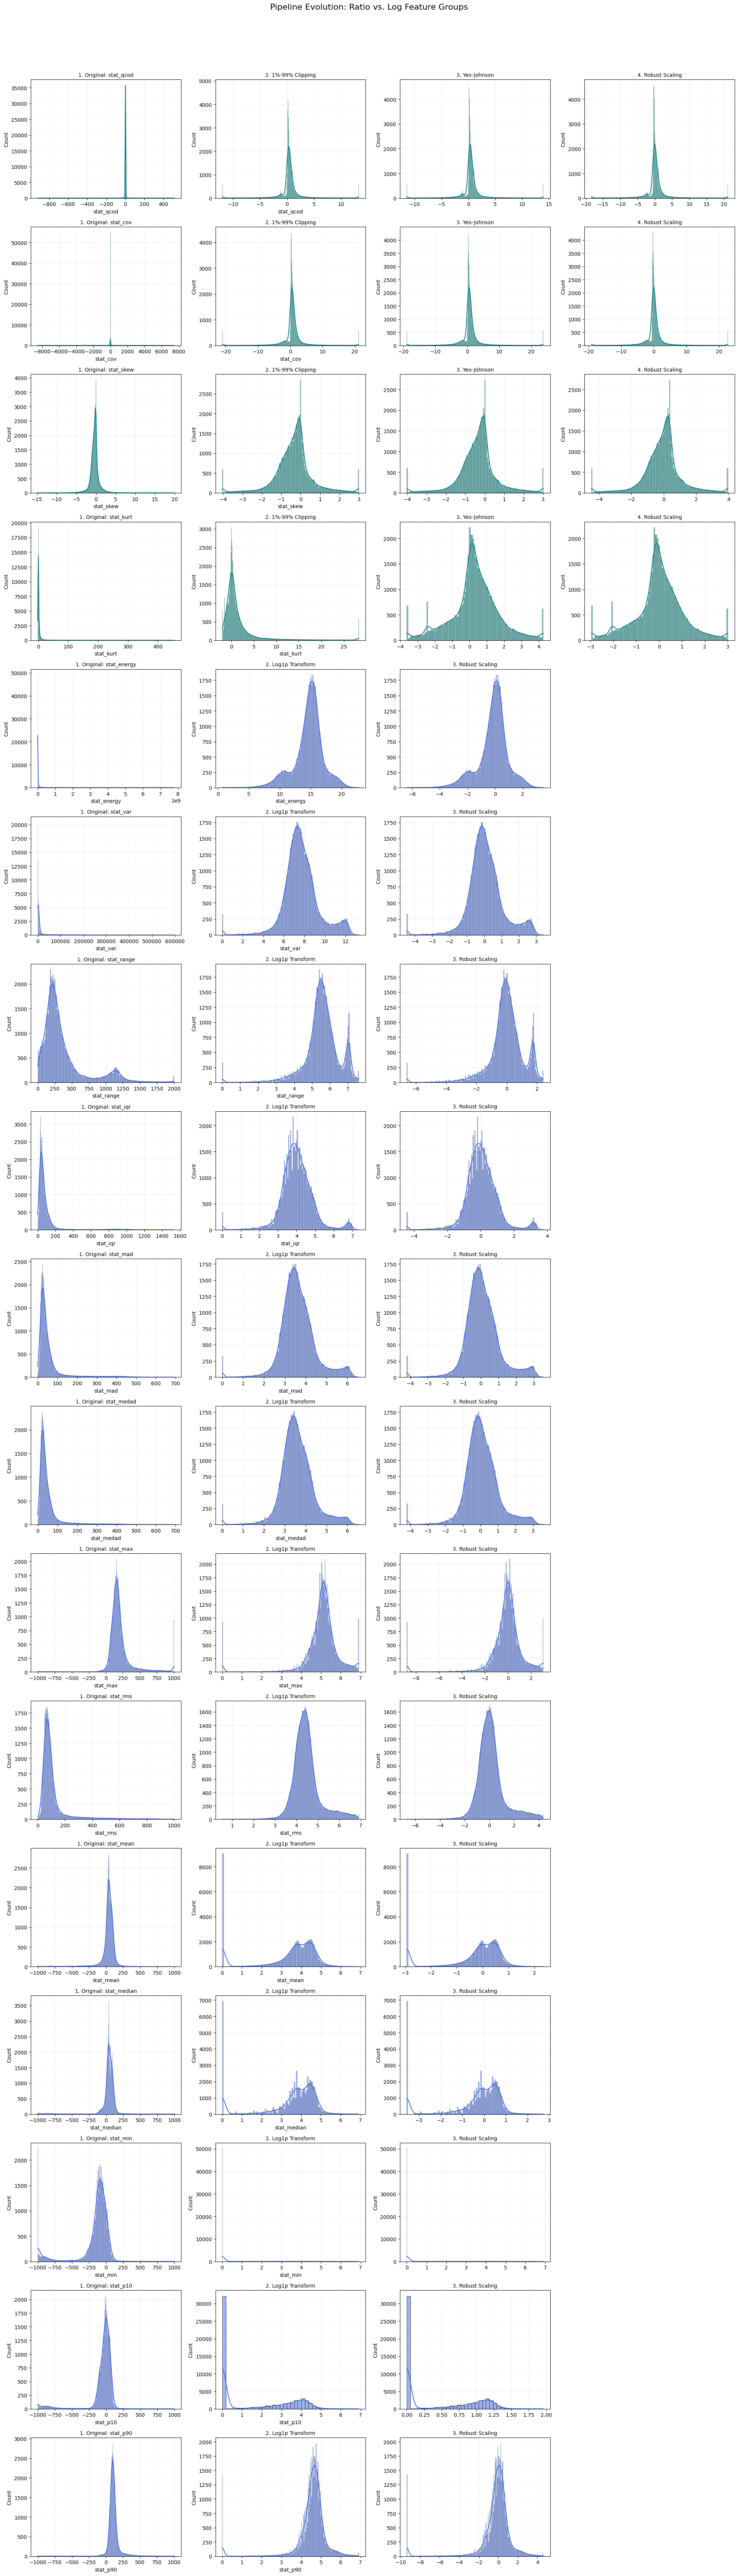

In [ ]:
LOG_FEATURES   = ["stat_energy", "stat_var", "stat_range", "stat_iqr", "stat_mad", "stat_medad", "stat_max", "stat_rms", 'stat_mean', 'stat_median', 'stat_min', 'stat_p10', 'stat_p90']
RATIO_FEATURES = ["stat_qcod", "stat_cov", "stat_skew", "stat_kurt"]

def plot_full_pipeline_comparison(data, features_to_plot):
    num_features = len(features_to_plot)

    fig, axes = plt.subplots(num_features, 4, figsize=(20, 4 * num_features))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    for row_idx, (feature_name, group_type) in enumerate(features_to_plot):
        raw = data[feature_name].dropna()
        stages = []
        titles = []
        color = "teal" if group_type == "ratio" else "royalblue"

        if group_type == "ratio":

            stages.append(raw)
            titles.append(f"1. Original: {feature_name}")

            low, high = raw.quantile(0.01), raw.quantile(0.99)
            clipped = raw.clip(low, high)
            stages.append(clipped)
            titles.append("2. 1%-99% Clipping")

            pt = PowerTransformer(method='yeo-johnson', standardize=False)
            transformed = pt.fit_transform(clipped.values.reshape(-1, 1)).flatten()
            stages.append(transformed)
            titles.append("3. Yeo-Johnson")

            sc = RobustScaler()
            scaled = sc.fit_transform(transformed.reshape(-1, 1)).flatten()
            stages.append(scaled)
            titles.append("4. Robust Scaling")

        elif group_type == "log":

            stages.append(raw)
            titles.append(f"1. Original: {feature_name}")

            logged = np.log1p(raw.clip(lower=0))
            stages.append(logged)
            titles.append("2. Log1p Transform")

            sc = RobustScaler()
            scaled = sc.fit_transform(logged.values.reshape(-1, 1)).flatten()
            stages.append(scaled)
            titles.append("3. Robust Scaling")
            stages.append(None)
            titles.append("")

        for col_idx in range(4):
            ax = axes[row_idx, col_idx] if num_features > 1 else axes[col_idx]
            if stages[col_idx] is not None:
                sns.histplot(stages[col_idx], kde=True, ax=ax, color=color)
                ax.set_title(titles[col_idx], fontsize=10)
                ax.grid(alpha=0.2)
            else:
                ax.axis('off')

    plt.suptitle("Pipeline Evolution: Ratio vs. Log Feature Groups", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Prepare the list of tuples for the function
features_to_visualize = [(col, "ratio") for col in RATIO_FEATURES] + [(col, "log") for col in LOG_FEATURES]

plot_full_pipeline_comparison(dataset, features_to_visualize)

### Power transformation on all features

In [19]:
def custom_scaling_v3(dataset, target_cols, is_train, scaler=None):
    df = dataset.copy()

    if is_train:
        scaler = {}
        
        # 1. Clipping pour neutraliser les artefacts extrêmes
        clip_bounds = {}
        for col in target_cols:
            low, high = df[col].quantile(0.01), df[col].quantile(0.99)
            clip_bounds[col] = (low, high)
            df[col] = df[col].clip(low, high)
            
        # 2. Yeo-Johnson pour normaliser les distributions
        # method='yeo-johnson' gère les valeurs positives et nulles
        pt = PowerTransformer(method='yeo-johnson', standardize=False)
        df[target_cols] = pt.fit_transform(df[target_cols])
        
        # 3. RobustScaler pour le centrage final
        sc = RobustScaler()
        df[target_cols] = sc.fit_transform(df[target_cols])
        
        # On stocke tout dans un dictionnaire unique pour l'inférence
        scaler["unified"] = (sc, target_cols, clip_bounds, pt)
        return df, scaler

    else:
        assert scaler is not None
        sc, cols, clip_bounds, pt = scaler["unified"]
        valid = [c for c in cols if c in df.columns]
        
        # Application des mêmes bornes de clipping du train
        for col in valid:
            if col in clip_bounds:
                low, high = clip_bounds[col]
                df[col] = df[col].clip(low, high)
        
        # Application de la transformation de puissance apprise
        df[valid] = pt.transform(df[valid])
        
        # Application du scaling robuste appris
        df[valid] = sc.transform(df[valid])

        return df, None
    
def plot_final_distributions(df, columns):
    num_cols = 4
    num_rows = int(np.ceil(len(columns) / num_cols))
    
    plt.figure(figsize=(20, 4 * num_rows))
    for i, col in enumerate(columns):
        plt.subplot(num_rows, num_cols, i + 1)
        sns.histplot(df[col], kde=True, color="darkslateblue")
        plt.title(f"Final: {col}")
        plt.axvline(0, color='red', linestyle='--', alpha=0.5) # Ligne de centrage
        plt.grid(alpha=0.2)
        
    plt.suptitle("Vérification Finale : Pipeline Universel Yeo-Johnson", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

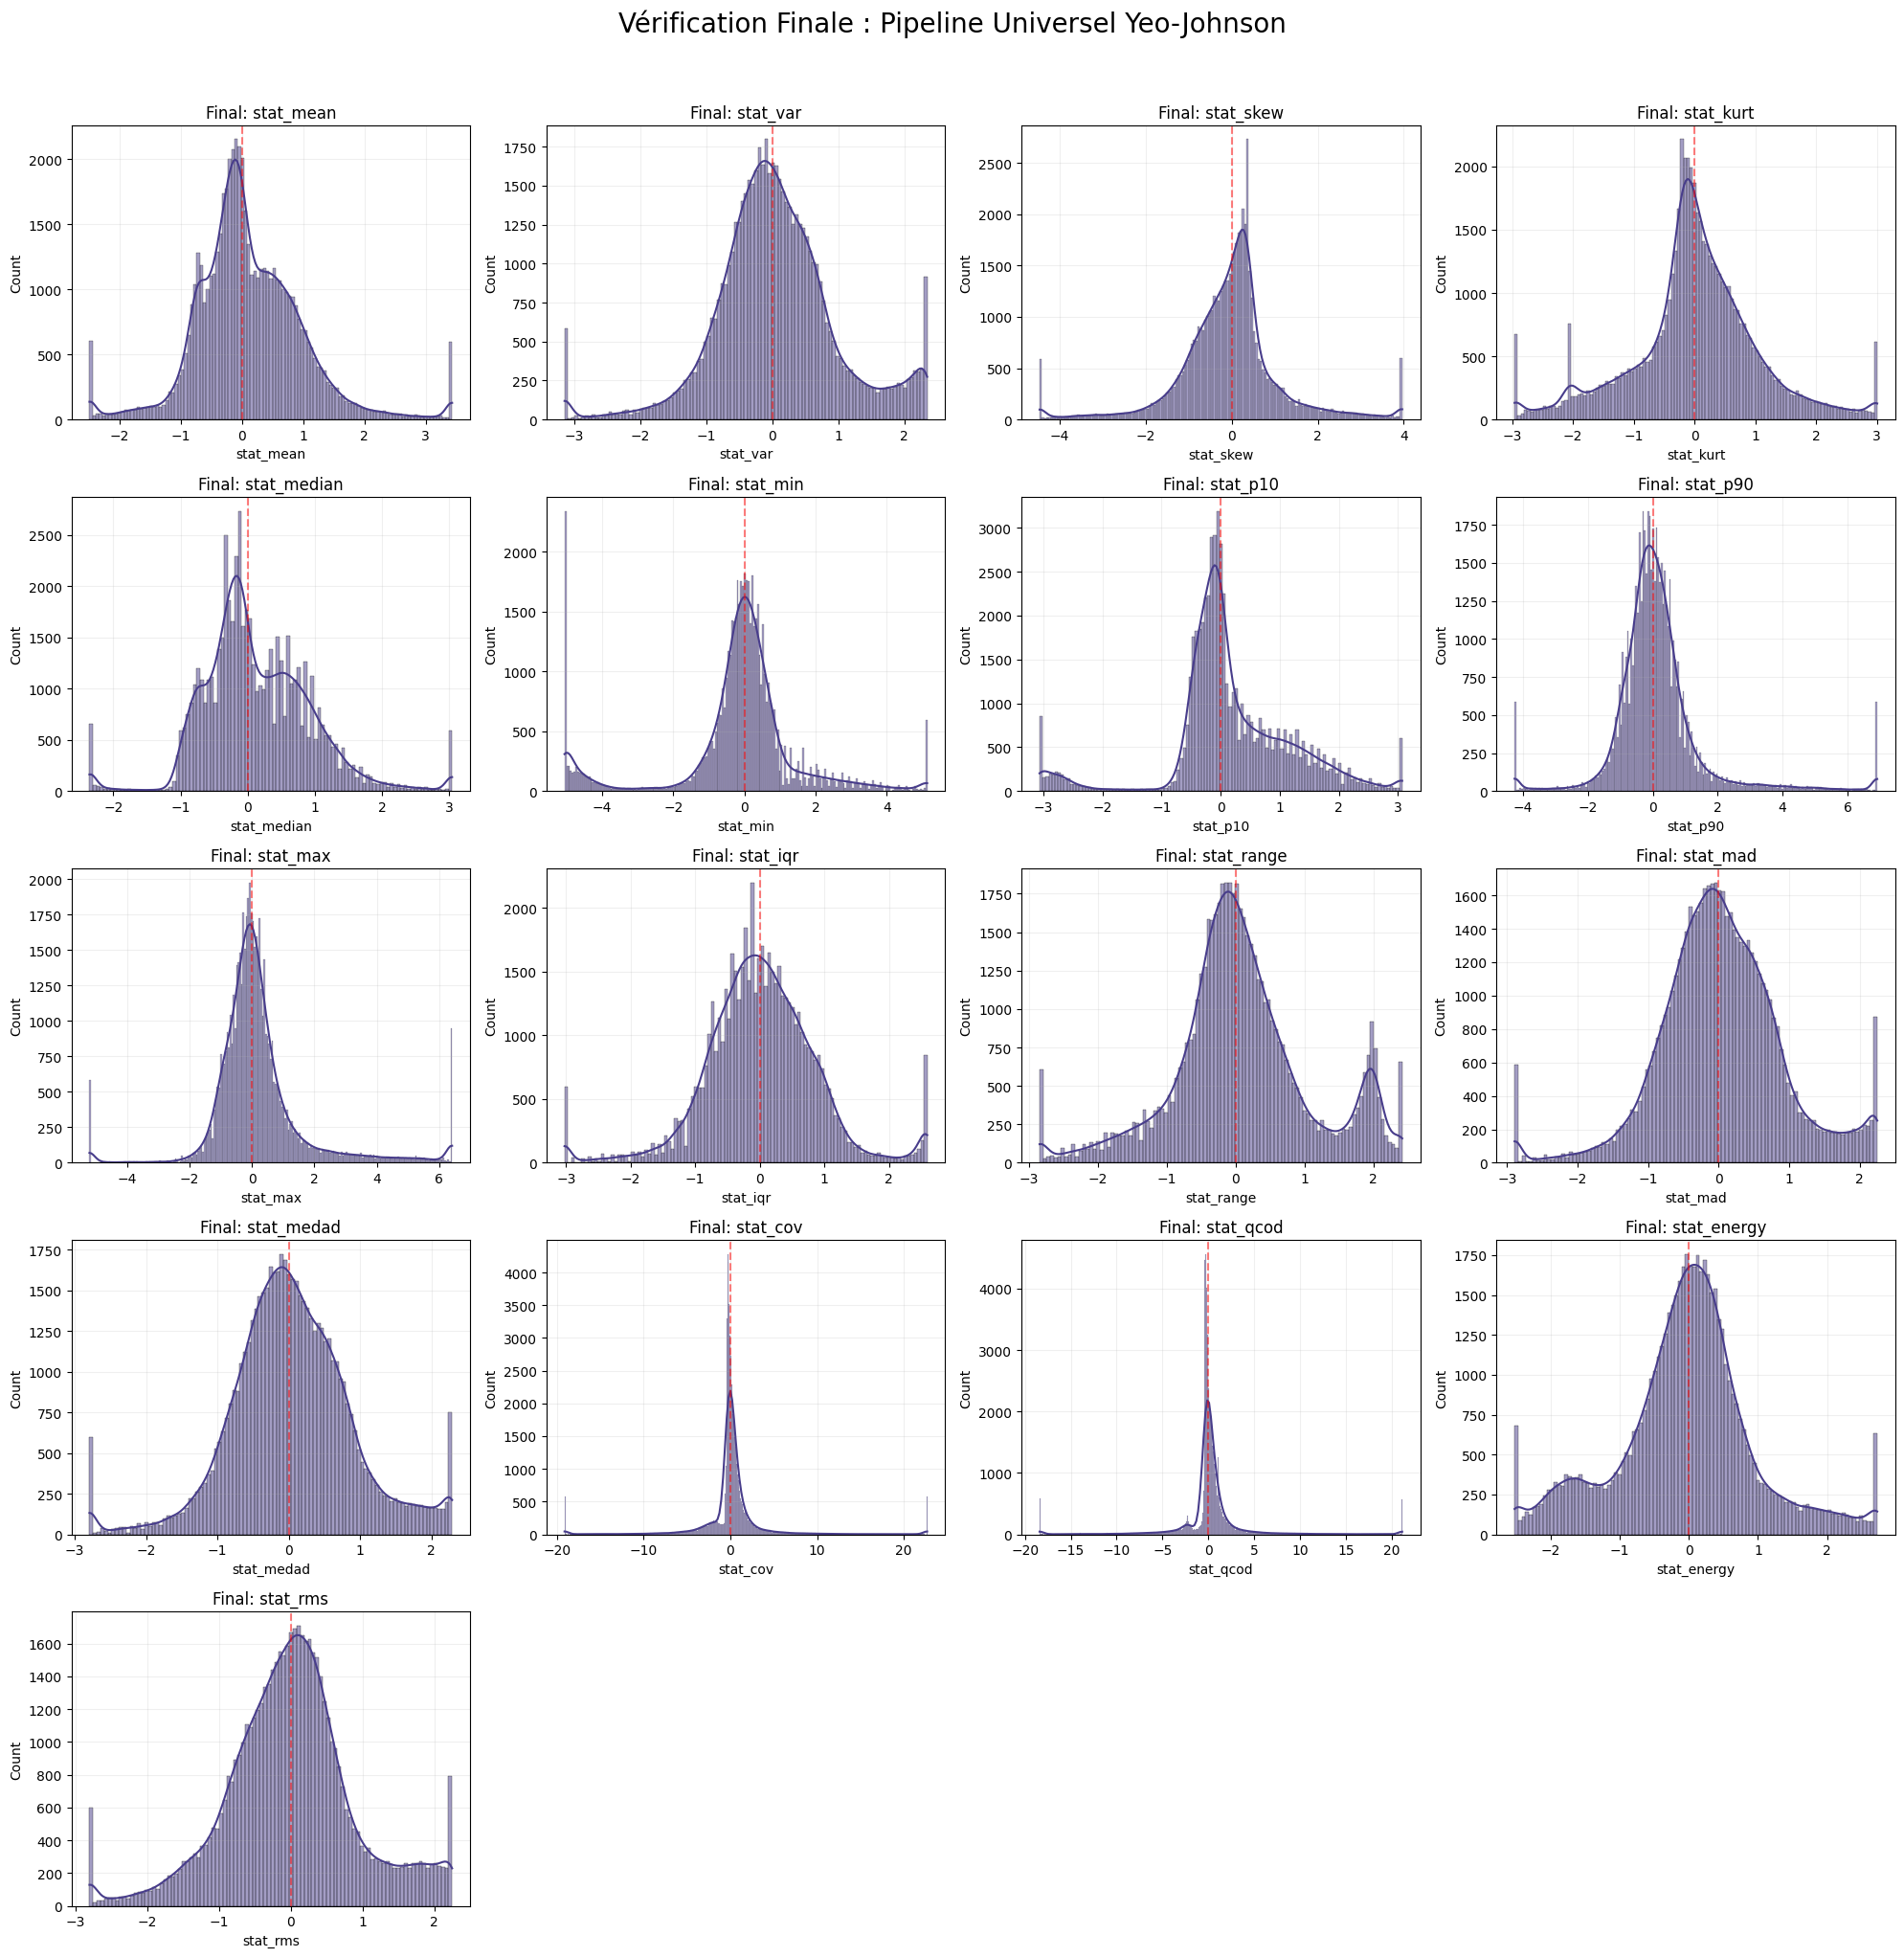

In [20]:
target_cols = [c for c in dataset.columns if c.startswith("stat_")]

df_transformed, scaler_obj = custom_scaling_v3(dataset, target_cols, is_train=True)
plot_final_distributions(df_transformed, target_cols)

In [21]:
print(f"{'Feature':<15} | {'Skewness After V3':<15}")
print("-" * 35)
for col in target_cols:
    print(f"{col:<15} | {df_transformed[col].skew():.4f}")

Feature         | Skewness After V3
-----------------------------------
stat_mean       | 0.5397
stat_var        | -0.0454
stat_skew       | -0.1664
stat_kurt       | -0.0920
stat_median     | 0.4502
stat_min        | -0.7722
stat_p10        | -0.3815
stat_p90        | 1.6692
stat_max        | 1.4263
stat_iqr        | -0.0719
stat_range      | 0.0312
stat_mad        | -0.0581
stat_medad      | -0.0472
stat_cov        | 0.8062
stat_qcod       | 0.5991
stat_energy     | 0.0300
stat_rms        | -0.0524


### Quantile Transformer effect

In [27]:
from sklearn.preprocessing import QuantileTransformer


def custom_scaling_v3(dataset, target_cols, is_train, scaler=None):
    df = dataset.copy()

    if is_train:
        scaler = {}
        
        # 1. Clipping pour neutraliser les artefacts extrêmes
        clip_bounds = {}
        for col in target_cols:
            low, high = df[col].quantile(0.01), df[col].quantile(0.99)
            clip_bounds[col] = (low, high)
            df[col] = df[col].clip(low, high)
            
        # 2. Yeo-Johnson pour normaliser les distributions
        # method='yeo-johnson' gère les valeurs positives et nulles
        qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
        df[target_cols] = qt.fit_transform(df[target_cols])
        
        # 3. RobustScaler pour le centrage final
        sc = RobustScaler()
        df[target_cols] = sc.fit_transform(df[target_cols])
        
        # On stocke tout dans un dictionnaire unique pour l'inférence
        scaler["unified"] = (sc, target_cols, clip_bounds, qt)
        return df, scaler

    else:
        assert scaler is not None
        sc, cols, clip_bounds, qt = scaler["unified"]
        valid = [c for c in cols if c in df.columns]
        
        # Application des mêmes bornes de clipping du train
        for col in valid:
            if col in clip_bounds:
                low, high = clip_bounds[col]
                df[col] = df[col].clip(low, high)
        
        # Application de la transformation de puissance apprise
        df[valid] = qt.transform(df[valid])
        
        # Application du scaling robuste appris
        df[valid] = sc.transform(df[valid])

        return df, None
    
def plot_final_distributions(df, columns):
    num_cols = 4
    num_rows = int(np.ceil(len(columns) / num_cols))
    
    plt.figure(figsize=(20, 4 * num_rows))
    for i, col in enumerate(columns):
        plt.subplot(num_rows, num_cols, i + 1)
        sns.histplot(df[col], kde=True, color="darkslateblue")
        plt.title(f"Final: {col}")
        plt.axvline(0, color='red', linestyle='--', alpha=0.5) # Ligne de centrage
        plt.grid(alpha=0.2)
        
    plt.suptitle("Vérification Finale : Pipeline Universel Yeo-Johnson", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

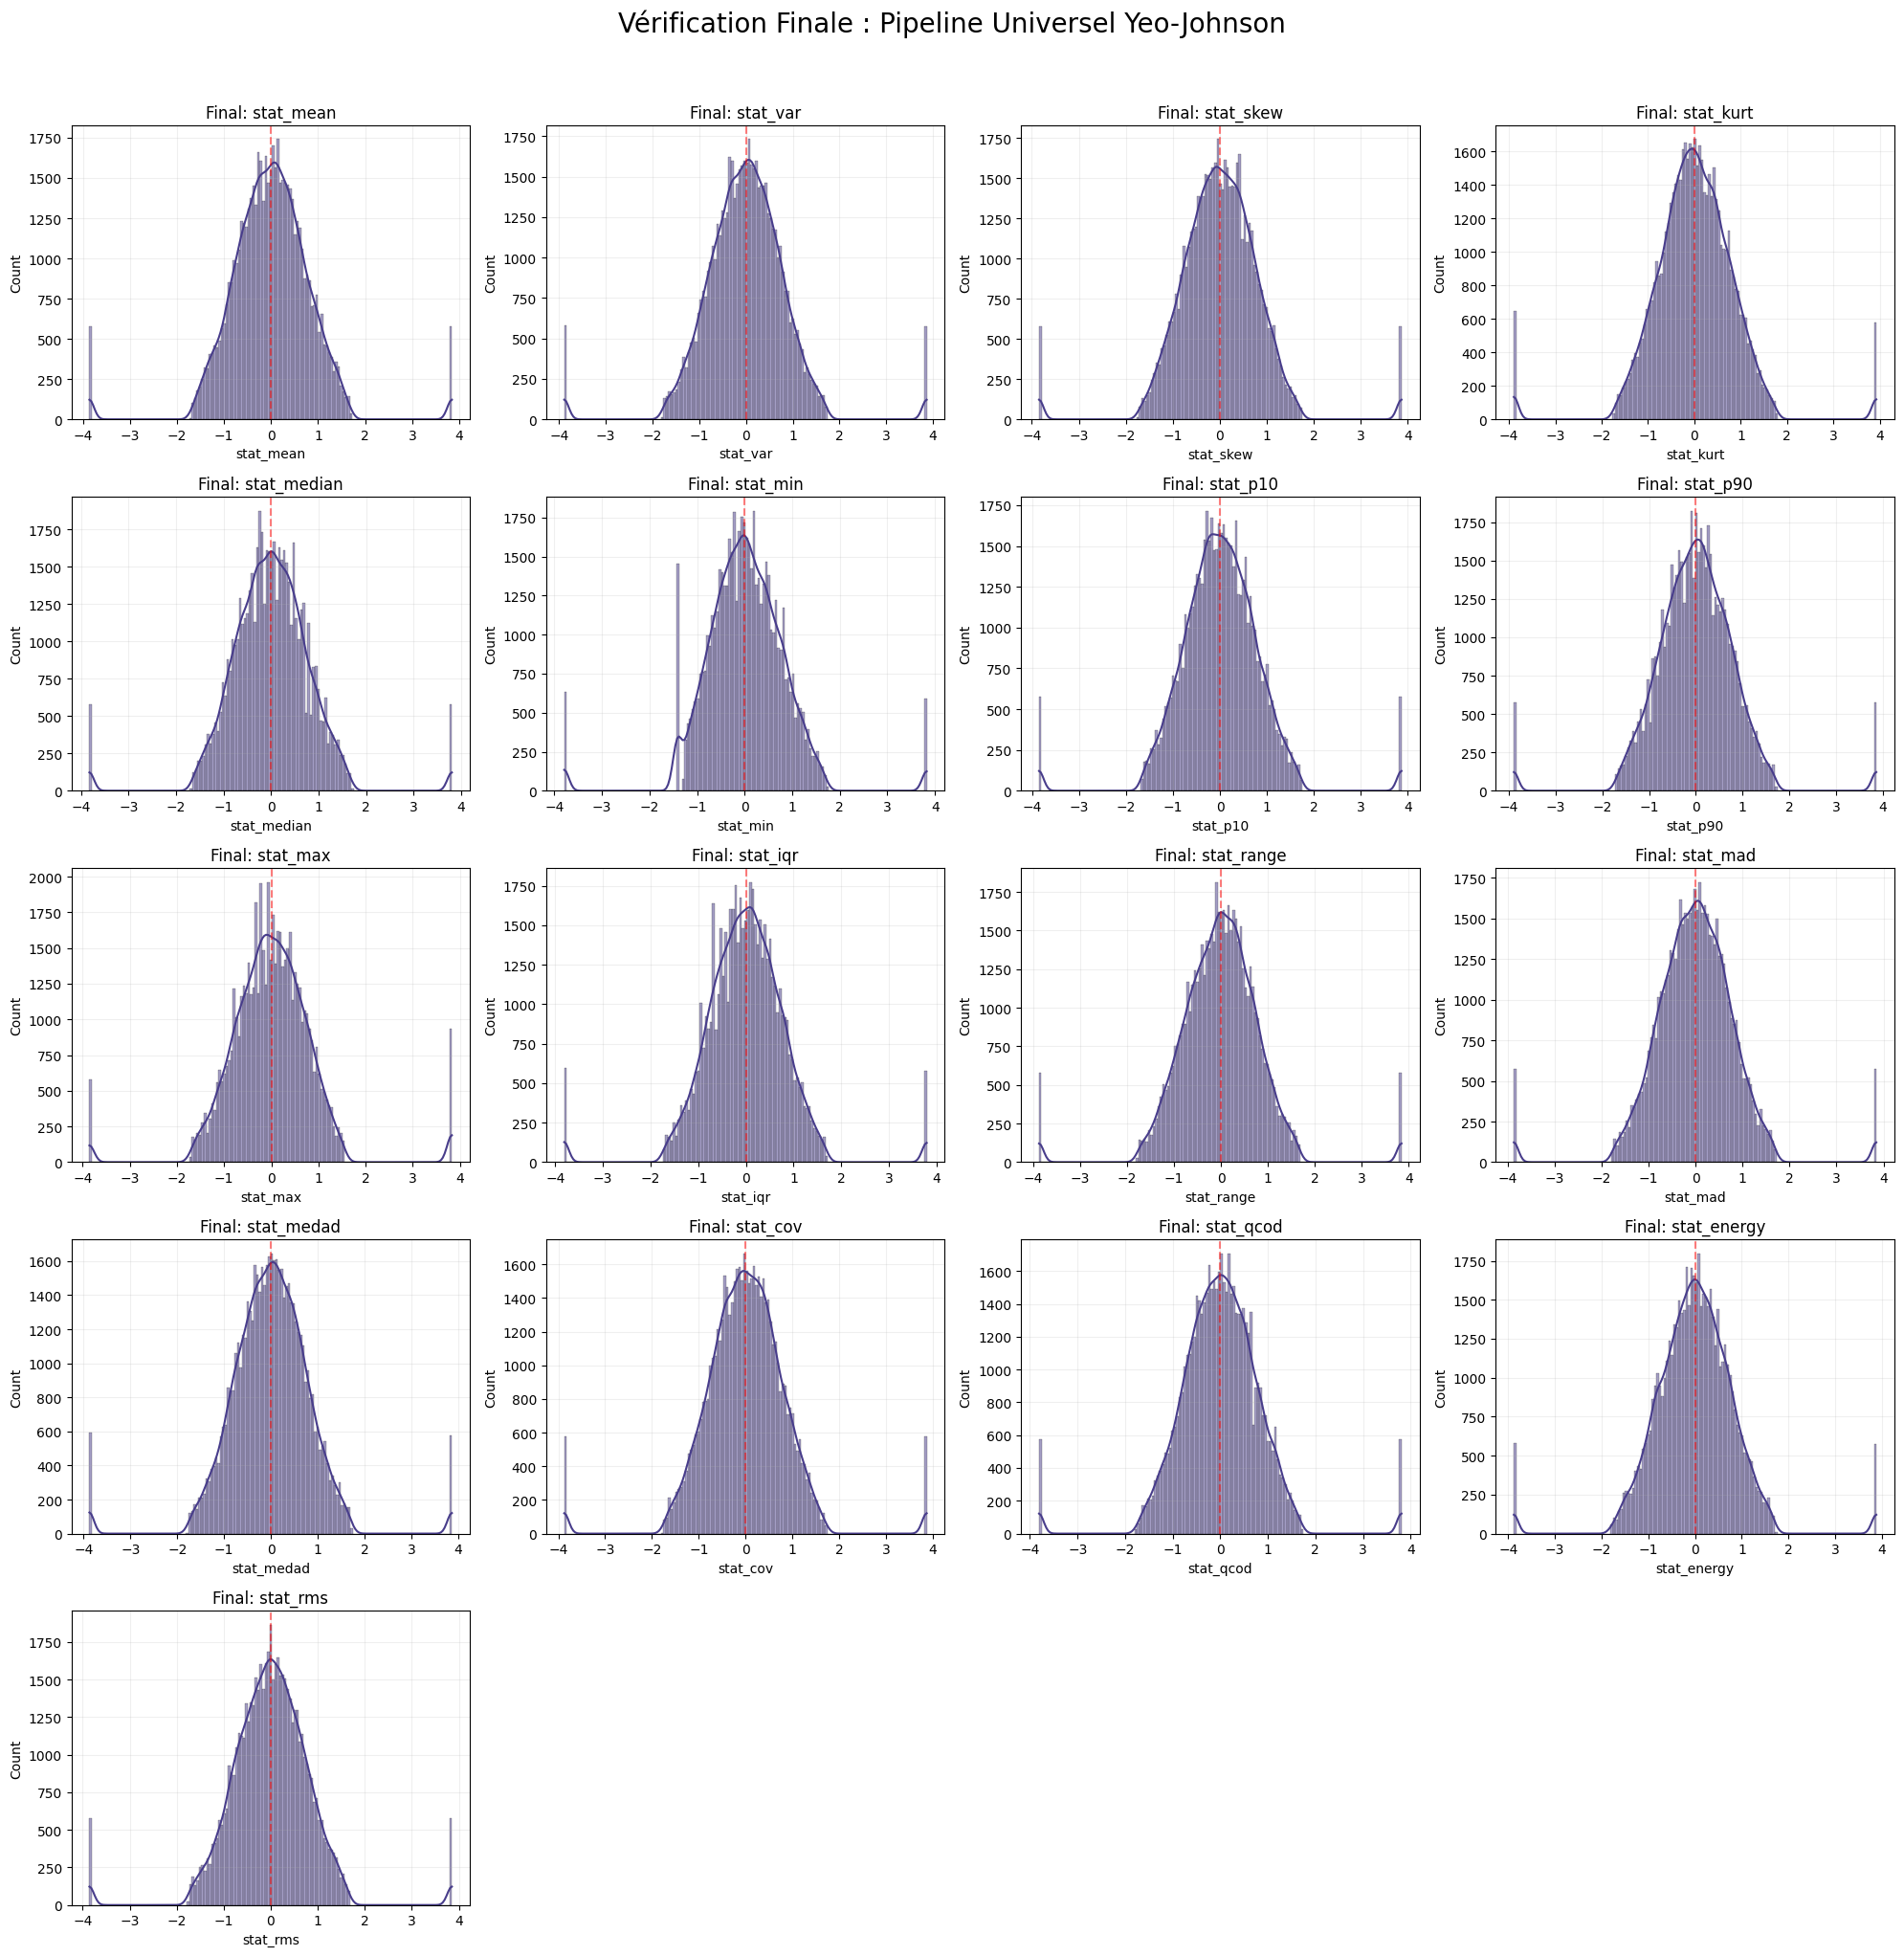

In [28]:
target_cols = [c for c in dataset.columns if c.startswith("stat_")]

df_transformed, scaler_obj = custom_scaling_v3(dataset, target_cols, is_train=True)
plot_final_distributions(df_transformed, target_cols)

In [29]:
print(f"{'Feature':<15} | {'Skewness After V3':<15}")
print("-" * 35)
for col in target_cols:
    print(f"{col:<15} | {df_transformed[col].skew():.4f}")

Feature         | Skewness After V3
-----------------------------------
stat_mean       | -0.0012
stat_var        | -0.0165
stat_skew       | 0.0049
stat_kurt       | -0.0728
stat_median     | 0.0043
stat_min        | -0.0259
stat_p10        | 0.0090
stat_p90        | -0.0158
stat_max        | 0.3571
stat_iqr        | -0.0370
stat_range      | -0.0227
stat_mad        | -0.0124
stat_medad      | -0.0296
stat_cov        | -0.0115
stat_qcod       | -0.0033
stat_energy     | -0.0068
stat_rms        | -0.0187
